[INFO] Loading Tulsi\Fresh\Fresh leaves\sample1_1.bil.hdr...
[INFO] Image Shape: 450x320 pixels, 168 bands
[INFO] Best Band Index: 108
[INFO] Inverting mask (background dominance)...
[INFO] Extracted 818 valid 5x5 patches.


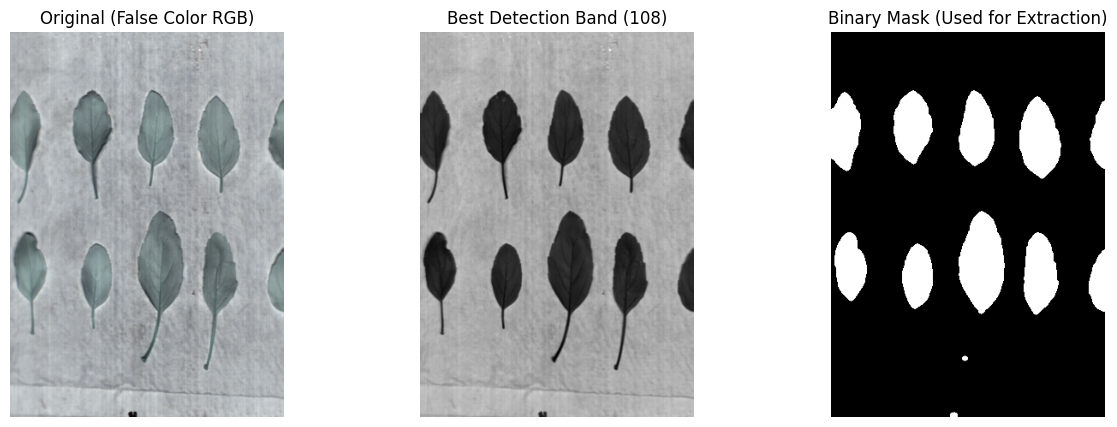

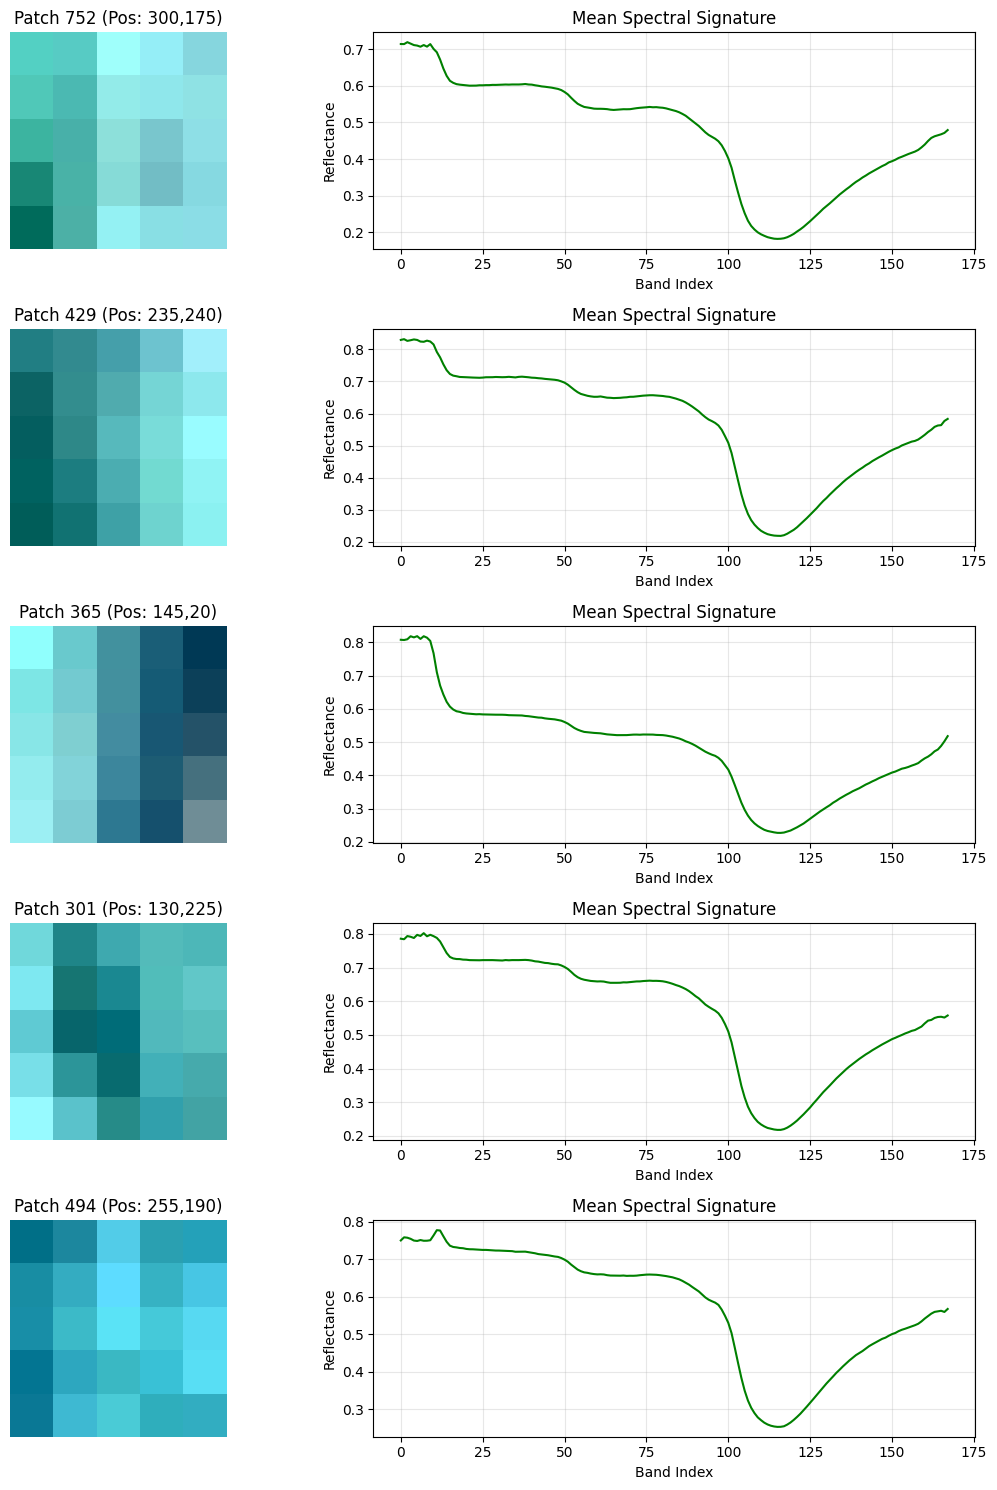

In [2]:
import os
from spectral import open_image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

# --- CONFIG ---
# Replace with an actual path to one of your .hdr files
sample_hdr_path = r"Tulsi\Fresh\Fresh leaves\sample1_1.bil.hdr" 
morph_kernel_primary = (7,7)
patch_size = 5  # Size of the patch (e.g., 5x5)

# --- HELPER FUNCTIONS (Copied from your script) ---
def load_hs(hdr_path):
    img = open_image(hdr_path)
    hs = img.load().astype(np.float32)
    bands_obj = getattr(img, "bands", None)
    return hs, bands_obj

def pick_best_band_index(hs):
    B = hs.shape[2]
    band_scores = [hs[:, :, b].std() for b in range(B)]
    best_idx = int(np.argmax(band_scores))
    return best_idx

def normalize_to_uint8(band):
    eps = 1e-12
    bn = (band - band.min()) / (band.max() - band.min() + eps)
    return (bn * 255).astype(np.uint8)

def segment_using_band(band_uint8, kernel_size=(7,7)):
    _, binary = cv2.threshold(band_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    return binary

# --- MAIN VISUALIZATION LOGIC ---

# 1. Load Data
if not os.path.exists(sample_hdr_path):
    print(f"[WARN] File not found: {sample_hdr_path}")
    # Try finding ANY .hdr file in Fresh
    search_dir = r"Tulsi\Tulsi\Fresh\Fresh leaves"
    if os.path.exists(search_dir):
        for f in os.listdir(search_dir):
            if f.endswith(".hdr"):
                sample_hdr_path = os.path.join(search_dir, f)
                print(f"[INFO] Found alternative: {sample_hdr_path}")
                break

print(f"[INFO] Loading {sample_hdr_path}...")
hs, _ = load_hs(sample_hdr_path)
H, W, B = hs.shape
print(f"[INFO] Image Shape: {H}x{W} pixels, {B} bands")

# 2. Pick Best Band & Normalize (Same as script)
best_band_idx = pick_best_band_index(hs)
print(f"[INFO] Best Band Index: {best_band_idx}")
band = hs[:, :, best_band_idx]
band_uint8 = normalize_to_uint8(band)

# 3. Segmentation (Same as script)
binary = segment_using_band(band_uint8, kernel_size=morph_kernel_primary)

# Guard: Invert if Background is detected as Foreground (heuristic)
num_labels_tmp, labels_tmp, stats_tmp, _ = cv2.connectedComponentsWithStats(binary)
max_area = 0
for i in range(1, num_labels_tmp):
    a = int(stats_tmp[i, cv2.CC_STAT_AREA])
    if a > max_area: max_area = a
if max_area > 0.5 * (H * W):
    print("[INFO] Inverting mask (background dominance)...")
    binary = 255 - binary
    
# 4. Extract Patches from Valid Areas
patches = []
patch_coords = []
step = patch_size  # Non-overlapping stride

for r in range(0, H - patch_size + 1, step):
    for c in range(0, W - patch_size + 1, step):
        # Extract binary mask patch
        mask_patch = binary[r:r+patch_size, c:c+patch_size]
        
        # Check if patch is ENTIRELY foreground (255)
        # You can relax this to > 50% foreground if strictly foreground is too restrictive
        if np.all(mask_patch == 255): 
            # Extract full spectral patch
            hs_patch = hs[r:r+patch_size, c:c+patch_size, :]
            patches.append(hs_patch)
            patch_coords.append((r,c))

print(f"[INFO] Extracted {len(patches)} valid {patch_size}x{patch_size} patches.")

# 5. Visualize
if len(patches) == 0:
    print("[ERROR] No valid patches found! Check mask.")
else:
    # Create RGB for context
    # Try using bands 60 (R), 40 (G), 20 (B) or similar
    rgb_bands = [min(60, B-1), min(40, B-1), min(20, B-1)] 
    rgb = hs[:,:,rgb_bands]
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original (False Color)
    ax[0].imshow(rgb)
    ax[0].set_title("Original (False Color RGB)")
    ax[0].axis('off')

    # Selected Detection Band
    ax[1].imshow(band_uint8, cmap='gray')
    ax[1].set_title(f"Best Detection Band ({best_band_idx})")
    ax[1].axis('off')

    # Binary Mask
    ax[2].imshow(binary, cmap='gray')
    ax[2].set_title("Binary Mask (Used for Extraction)")
    ax[2].axis('off')
    
    plt.show()

    # Visualize Random Patches
    num_show = 5
    indices = random.sample(range(len(patches)), min(len(patches), num_show))
    
    fig, axes = plt.subplots(num_show, 2, figsize=(12, 3*num_show))
    if num_show == 1: axes = [axes] # Handle case of 1 patch

    for i, idx in enumerate(indices):
        p = patches[idx]
        r, c = patch_coords[idx]
        
        # Mean spectral signature of this patch
        mean_spec = np.mean(p, axis=(0,1))
        
        # Make patch image (using same RGB bands)
        patch_img = p[:,:,rgb_bands]
        patch_img = (patch_img - patch_img.min()) / (patch_img.max() - patch_img.min())

        # Plot Patch Image
        axes[i][0].imshow(patch_img)
        axes[i][0].set_title(f"Patch {idx} (Pos: {r},{c})")
        axes[i][0].axis('off')
        
        # Plot Spectrum
        axes[i][1].plot(mean_spec, color='green')
        axes[i][1].set_title("Mean Spectral Signature")
        axes[i][1].set_xlabel("Band Index")
        axes[i][1].set_ylabel("Reflectance")
        axes[i][1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()